# WSDP Quick Start Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sdp-team/wsdp/blob/main/examples/wsdp_tutorial.ipynb)

This notebook demonstrates the basic usage of WSDP (Wi-Fi Sensing Data Processing).

## What you'll learn:
- How to install WSDP
- How to download datasets
- How to run the full pipeline
- How to use individual components

## 1. Installation

In [ ]:
# Install WSDP
!pip install wsdp

# Or install from source (for latest features)
# !pip install git+https://github.com/sdp-team/wsdp.git

## 2. Download Sample Data

WSDP supports multiple datasets. Let's download a sample dataset:

In [14]:
from wsdp import download

# Download Widar dataset (requires authentication)
# You can get a JWT token from the dataset provider
# download('widar', str(base_dir / 'data' / 'widar'), token='YOUR_JWT_TOKEN')

# For this demo, we'll create synthetic data
import numpy as np
from pathlib import Path

# Use the notebook's directory as the base path (works on all OS)
base_dir = Path.cwd()
data_dir = base_dir / 'data' / 'demo'
data_dir.mkdir(parents=True, exist_ok=True)

# Create sample CSI data
sample_data = np.random.randn(100, 200, 30, 3) + 1j * np.random.randn(100, 200, 30, 3)
np.save(data_dir / 'sample_csi.npy', sample_data)
print(f"Created sample data with shape: {sample_data.shape}")

Created sample data with shape: (100, 200, 30, 3)


## 3. Data Processing

Let's explore WSDP's preprocessing capabilities:

In [16]:
from wsdp.algorithms import wavelet_denoise_csi, phase_calibration
from wsdp.algorithms.visualization import plot_csi_heatmap
import matplotlib.pyplot as plt

# Load sample data (shape: N, T, F, A)
from pathlib import Path
base_dir = Path.cwd()
csi_data = np.load(base_dir / 'data' / 'demo' / 'sample_csi.npy')
print(f"Original data shape: {csi_data.shape}")

# Take the first sample for processing (algorithms expect shape T, F, A)
csi_sample = csi_data[0]

# Apply phase calibration
calibrated = phase_calibration(csi_sample)
print("Phase calibration applied")

# Apply wavelet denoising
denoised = wavelet_denoise_csi(calibrated)
print("Wavelet denoising applied")

Original data shape: (100, 200, 30, 3)
Phase calibration applied
Wavelet denoising applied


## 4. Visualization

Visualize the CSI data:

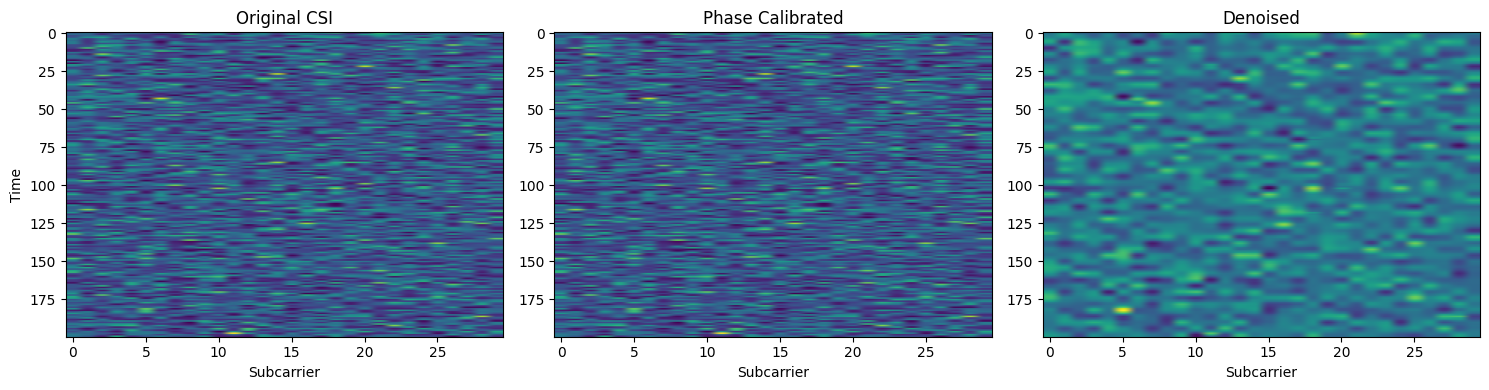

In [17]:
# Plot heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].imshow(np.abs(csi_data[0, :, :, 0]), aspect='auto', cmap='viridis')
axes[0].set_title('Original CSI')
axes[0].set_xlabel('Subcarrier')
axes[0].set_ylabel('Time')

# Calibrated
axes[1].imshow(np.abs(calibrated[:, :, 0]), aspect='auto', cmap='viridis')
axes[1].set_title('Phase Calibrated')
axes[1].set_xlabel('Subcarrier')

# Denoised
axes[2].imshow(np.abs(denoised[:, :, 0]), aspect='auto', cmap='viridis')
axes[2].set_title('Denoised')
axes[2].set_xlabel('Subcarrier')

plt.tight_layout()
plt.show()

## 5. Model Training

Run the full training pipeline:

In [19]:
from wsdp import pipeline
from pathlib import Path

# Note: This requires actual dataset files
# For demo purposes, we'll show the API

base_dir = Path.cwd()
data_path = base_dir / 'data' / 'widar'
output_path = base_dir / 'output'

if data_path.exists():
    # pipeline(
    #     input_path=str(data_path),
    #     output_folder=str(output_path),
    #     dataset='widar',
    #     learning_rate=1e-3,
    #     num_epochs=10,
    # )
    print("Training started!")
else:
    print("Pipeline API ready to use!")
    print(f"Dataset not found at {data_path}. Place your Widar data there to run training.")

Pipeline API ready to use!
Dataset not found at D:\Documents\pythonProjects\Sensing-Data-Protocol\examples\data\xrf55. Place your Widar data there to run training.


## 6. Inference

Use a trained model for prediction:

In [ ]:
from wsdp import predict

# Create sample data for inference
test_csi = np.random.randn(5, 200, 30, 3) + 1j * np.random.randn(5, 200, 30, 3)

# Run inference (requires trained model)
# predictions = predict(
#     csi_data=test_csi,
#     model_path='output/best_checkpoint.pth',
#     num_classes=6,
# )

print(f"Test data shape: {test_csi.shape}")
print("Inference API ready!")

## 7. CLI Usage

WSDP also provides a command-line interface:

In [ ]:
# Check version
!wsdp --version

# List available datasets
!wsdp list --verbose

## Next Steps

- Check out the [full documentation](https://sdp-team.github.io/wsdp)
- Explore [examples](https://github.com/sdp-team/wsdp/tree/main/examples)
- Read the [API Reference](https://sdp-team.github.io/wsdp/api/)
- Contribute on [GitHub](https://github.com/sdp-team/wsdp)

## Citation

```bibtex
@software{wsdp2026,
  author = {Cui, Yuanhao and WSDP Team},
  title = {WSDP: Wi-Fi Sensing Data Processing},
  url = {https://github.com/sdp-team/wsdp},
  version = {0.2.0},
  year = {2026},
}
```